In [1]:
%matplotlib inline

import datetime as dt
import glob
import os
import sys
from pathlib import Path

import dill as pk
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import latcom.utils.map_utils as mu
from latcom.utils.optical_loading import UXM_dict, add_iv_info, get_fpa_temps, pwv_interp, ufm_dict

from sotodlib import core

%load_ext autoreload
%autoreload 2

In [2]:
# lat_baseline = core.AxisManager.load("v3r7_baseline_pwv_el_sweep_LAT.h5")
# lat_goal = core.AxisManager.load("v3r7_goal_pwv_el_sweep_LAT.h5")
# edx = np.where( np.isclose(lat_goal.elevations,50) )[0][0]

In [3]:
with open("../../data/opt_load_det.pk", "rb") as f:
    optical_loading_detectors = pk.load(f)
#det_match_path = "/so/home/mrandall/Analysis/Detmatching/Matched_Dark_Cal/lat/"
#detmatches = glob.glob(det_match_path + "*.h5")

In [4]:
## context for loading data
ctx = core.Context("../../ctxs/smurf_detsets_local.yaml")

In [5]:
ufm = "mv11"

if "uv" in ufm:
    ufm_type = "UHF"
    ufm_1 = "UHF_1"
    ufm_2 = "UHF_2"
    low_freq = "220"
    high_freq = "280"

elif "mv" in ufm:
    ufm_type = "MF"
    ufm_1 = "MF_1"
    ufm_2 = "MF_2"
    low_freq = "090"
    high_freq = "150"

else:
    ufm_type = "LF"
    ufm_1 = "LF_1"
    ufm_2 = "LF_2"
    low_freq = "030"
    high_freq = "040"

start = dt.datetime(2026, 4, 26, tzinfo=dt.timezone.utc)
end = dt.datetime(2026, 7, 15, tzinfo=dt.timezone.utc)
obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='oper' and subtype=='iv'"
    " and stream_ids_list == 'ufm_{}'".format(ufm)
)

In [6]:
try:
    with open(f"../../ivs_{ufm}.pk", "rb") as f:
        iv_dict = pk.load(f)
    psats = iv_dict["psats"]
    bgmaps = iv_dict["bgmaps"]
    obs_ids = iv_dict["obs_ids"]
    pwvs = iv_dict["pwvs"]
    els = iv_dict["els"]
    ufm_temps = iv_dict["ufm_temps"]

except FileNotFoundError:
    pwv = pwv_interp()
    ctx = core.Context("../../ctxs/smurf_detsets_local.yaml")
    
    psats = []
    bgmaps = []
    obs_ids = []
    pwvs = []
    els = []
    ufm_temps = []
    
    for i in range(len(obs_list)):
        print("\r", np.round(i/len(obs_list), 2), end="", flush=True)
        sys.stdout.write(f"\033[")
        obs = obs_list[i]
        obs_id = obs["obs_id"]
        meta = ctx.get_meta(obs)
    
        try:
            add_iv_info(meta, ctx)
            iv_dict[obs_id] = {}
        except FileNotFoundError:
            print(meta.obs_info.obs_id)
            continue
    
        psats.append(meta.iv["p_sat"])
        bgmaps.append(meta.iv["bgmap"][...])
        obs_ids.append(obs_id)
        pwvs.append(float(pwv((obs["start_time"] + obs["stop_time"]) / 2)))
        ufm_temps.append(float(get_fpa_temps(obs_list[i : i + 1])[0]))
        els.append(meta.obs_info.el_center)
    dump_dict = {"psats":psats,
                 "bgmaps":bgmaps,
                 "obs_ids":obs_ids,
                 "pwvs":pwvs,
                 "ufm_temps":ufm_temps,
                 "els": els,
                }
    with open(f"../../ivs_{ufm}.pk", "wb") as f:
        pk.dump(dump_dict, f)

In [7]:
nsamps = np.amax([len(arr) for arr in psats])
nivs = len(psats)

lopts_low = []
lopts_high = []

for iv, psat in enumerate(psats):
    lopts_low.append([])
    lopts_high.append([])
    for i, cur_psat in enumerate(psat):
        if bgmaps[iv][i] in [0, 1, 4, 5, 8, 9]:
            freq = "low"
        elif bgmaps[iv][i] in [2, 3, 6, 7, 10, 11]:
            freq = "high"
        else:
            continue
        n = UXM_dict[freq][ufm]["n"]
        lopt = (
        UXM_dict[freq][ufm]["psat_dark"]
            - cur_psat
            + UXM_dict[freq][ufm]["kappa"] * (0.1**n - ufm_temps[iv]**n)
        )
        if lopt < -100:
            continue 
        if freq == "low":
            lopts_low[iv].append(float(lopt))
        else:
            lopts_high[iv].append(float(lopt))


In [8]:
saturated = np.zeros(len(psats))
for i, psat in enumerate(psats):
    saturated[i] = len(np.where(psat <= 0.1)[0]) + sum(np.isnan(x) for x in psat)

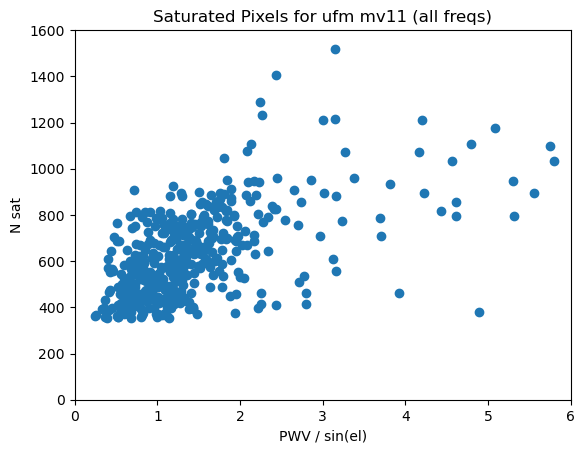

In [9]:
plt.scatter(pwvs / np.sin(np.deg2rad(els)), saturated)
plt.title(f"Saturated Pixels for ufm {ufm} (all freqs)")

plt.xlabel("PWV / sin(el)")
plt.ylabel("N sat")

plt.xlim(0, 6)
plt.ylim(0, 1600)

output_dir = Path(f"../../plts/sats/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"sat_{ufm}.pdf", dpi=600)
plt.savefig(output_dir / f"sat_{ufm}.png", dpi=600)

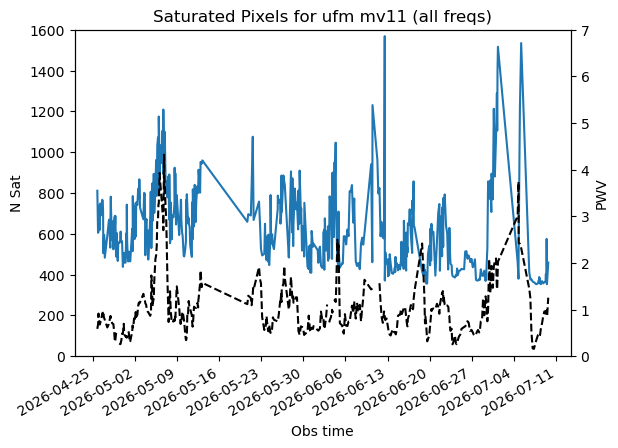

In [10]:
times = np.array([dt.datetime.fromtimestamp(int(obs_id.split("_")[1])) for obs_id in obs_ids])

fig, ax = plt.subplots()

ax.plot(times, saturated)

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gcf().autofmt_xdate()

ax.set_xlabel("Obs time")
ax.set_ylabel("N Sat")
ax.set_ylim(0, 1600)
ax2.set_ylim(0, 7)
ax2.set_ylabel("PWV")

plt.title(f"Saturated Pixels for ufm {ufm} (all freqs)")

output_dir = Path(f"../../plts/sats/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"time_sat_{ufm}.pdf", dpi=600)
plt.savefig(output_dir / f"time_sat_{ufm}.png", dpi=600)

In [11]:
fname = "../../data/lopt_fits.pk"
if os.path.exists(fname):
    with open(fname, "rb") as f:
        lopt_fit_dict = pk.load(f)
else:
    lopt_fit_dict = {}

indv_lopts_fname = "../../data/lopt_indv.pk"
if os.path.exists(indv_lopts_fname):
    with open(indv_lopts_fname, "rb") as f:
        lopt_indv_dict = pk.load(f)
else:
    lopt_indv_dict = {}

sat_fname = "../../data/lopt_sat.pk"
if os.path.exists(sat_fname):
    with open(sat_fname, "rb") as f:
        sat_dict = pk.load(f)
else:
    sat_dict = {}

In [12]:
saturated_low = np.zeros(len(psats))
saturated_high = np.zeros(len(psats))

for i, psat in enumerate(psats):
    #I'm pretty sure I'm just splitting the uncategorizable saturated dets evenly between low and high
    other_sat = int(len([j for j in range(len(bgmaps[i])) if bgmaps[i][j] not in np.arange(0, 12, 1)])/ 2)
    low_flags = [j for j in range(len(bgmaps[i])) if bgmaps[i][j] in [0,1,4,5,8,9]]
    saturated_low[i] = (len(np.where(psat[low_flags] <= 0.1)[0]) + sum(np.isnan(x) for x in psat[low_flags]) + other_sat)
    high_flags = [j for j in range(len(bgmaps[i])) if bgmaps[i][j] in [2, 3, 6, 7, 10, 11]]
    saturated_high[i] = (len(np.where(psat[high_flags] <= 0.1)[0]) + sum(np.isnan(x) for x in psat[high_flags]) + other_sat)

sat_dict[ufm] = {
    "pwv_sinel": pwvs / np.sin(np.deg2rad(els)),
    "obs_id": obs_ids,
    "low": saturated_low,
    "high": saturated_high,
}
with open(sat_fname, "wb") as f:
    pk.dump(sat_dict, f)

## Fit data

In [13]:
from scipy.optimize import curve_fit

def func(x, L0, Lwet):
    return L0 + Lwet * x

In [14]:
xdata, ydata = (pwvs / np.sin(np.deg2rad(els))), np.array([np.nanmedian(lopt_low) for lopt_low in lopts_low])
pwvcut = np.where((xdata <= 3.0) & (0.5 < ydata) & (ydata < 100))


/tmp/ipykernel_1167346/2870750986.py:1: RuntimeWarning: All-NaN slice encountered
  xdata, ydata = (pwvs / np.sin(np.deg2rad(els))), np.array([np.nanmedian(lopt_low) for lopt_low in lopts_low])


In [ ]:
np.nanmean(np.array(lopts_low[0])[np.where(np.array(lopts_low[0]) > -10)[0]])

In [ ]:
xdata, ydata = (pwvs / np.sin(np.deg2rad(els))), np.array([np.nanmedian(lopt_low) for lopt_low in lopts_low])

pwvcut = np.where((xdata <= 3.0) & (0.5 < ydata) & (ydata < 100))

xdata = xdata[pwvcut]
ydata = ydata[pwvcut]

lopt_indv_dict[ufm] = {low_freq: {"pwv_sinel": xdata, "lopt": ydata}}

popt, pcov = curve_fit(func, xdata, ydata)

lopt_fit_dict[ufm] = {low_freq: {}, high_freq: {}}
lopt_fit_dict[ufm][low_freq]["popt"] = popt
lopt_fit_dict[ufm][low_freq]["pcov"] = pcov


plt.plot(optical_loading_detectors["pwv_sin_el"],  func(optical_loading_detectors["pwv_sin_el"], *popt), "g", label="fit: L0=%5.3f, Lwet=%5.3f" % tuple(popt),)
plt.scatter(xdata, ydata)

plt.plot(optical_loading_detectors["pwv_sin_el"], 1e12 * optical_loading_detectors["baseline"][ufm_type][ufm_1], label="v3r8 baseline, el=50",)
plt.plot(optical_loading_detectors["pwv_sin_el"], 1e12 * optical_loading_detectors["goal"][ufm_type][ufm_1], label="v3r8 goal, el=50",)

plt.xlabel("PWV / sin(el)")
plt.ylabel("Lotp (pW, array median)")

plt.title(f"Optical Loading for ufm {ufm}, {low_freq}GHz")

plt.xlim(0, 4)

if low_freq == "030":
    plt.ylim(0,10) #TODO: update
elif low_freq == "090":
    plt.ylim(0, 3)
elif low_freq == "220":
    plt.ylim(0, 25)

plt.legend()

output_dir = Path(f"../../plts/lopts/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"lopt_{ufm}_{low_freq}.pdf", dpi=600)
plt.savefig(output_dir / f"lopt_{ufm}_{low_freq}.png", dpi=600)

In [ ]:
xdata, ydata = (pwvs / np.sin(np.deg2rad(els))), np.array([np.nanmedian(lopt_high) for lopt_high in lopts_high])

pwvcut = np.where((xdata <= 3.0) & (0.5 < ydata) & (ydata < 100))

xdata = xdata[pwvcut]
ydata = ydata[pwvcut]

lopt_indv_dict[ufm] = {low_freq: {"pwv_sinel": xdata, "lopt": ydata}}

popt, pcov = curve_fit(func, xdata, ydata)

lopt_fit_dict[ufm] = {low_freq: {}, high_freq: {}}
lopt_fit_dict[ufm][high_freq]["popt"] = popt
lopt_fit_dict[ufm][high_freq]["pcov"] = pcov


plt.plot(optical_loading_detectors["pwv_sin_el"],  func(optical_loading_detectors["pwv_sin_el"], *popt), "g", label="fit: L0=%5.3f, Lwet=%5.3f" % tuple(popt),)
plt.scatter(xdata, ydata)

plt.plot(optical_loading_detectors["pwv_sin_el"], 1e12 * optical_loading_detectors["baseline"][ufm_type][ufm_2], label="v3r8 baseline, el=50",)
plt.plot(optical_loading_detectors["pwv_sin_el"], 1e12 * optical_loading_detectors["goal"][ufm_type][ufm_2], label="v3r8 goal, el=50",)

plt.xlabel("PWV / sin(el)")
plt.ylabel("Lotp (pW, array median)")

plt.title(f"Optical Loading for ufm {ufm}, {high_freq}GHz")

plt.xlim(0, 4)

if low_freq == "030":
    plt.ylim(0,10) #TODO: update
elif low_freq == "090":
    plt.ylim(0, 3)
elif low_freq == "220":
    plt.ylim(0, 25)

plt.legend()

output_dir = Path(f"../../plts/lopts/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"lopt_{ufm}_{high_freq}.pdf", dpi=600)
plt.savefig(output_dir / f"lopt_{ufm}_{high_freq}.png", dpi=600)

In [ ]:
with open(fname, "wb") as f:
    pk.dump(lopt_fit_dict, f)
with open(indv_lopts_fname, "wb") as f:
    pk.dump(lopt_indv_dict, f)

# All Lopts

In [1020]:
import pandas as pd
import seaborn as sns

fname = "lopt_fits.pk"

with open(fname, "rb") as f:
    lopt_dict = pk.load(f)


def func(x, L0, Lwet):
    return L0 + Lwet * x

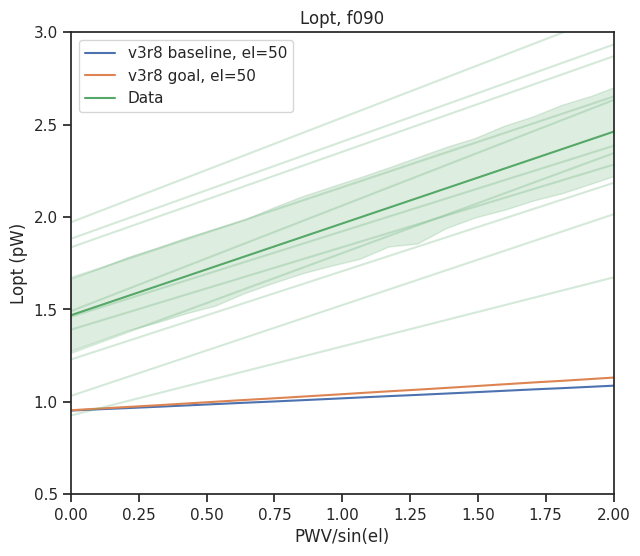

In [1021]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

plt.plot(
    optical_loading_detectors["pwv_sin_el"],
    1e12 * optical_loading_detectors["baseline"]["MF"]["MF_1"],
    label="v3r8 baseline, el=50",
)
plt.plot(
    optical_loading_detectors["pwv_sin_el"],
    1e12 * optical_loading_detectors["goal"]["MF"]["MF_1"],
    label="v3r8 goal, el=50",
)

xs = []
ys = []
for key in lopt_dict.keys():
    if "mv" in key:
        popt = lopt_dict[key]["090"]["popt"]
        y = func(optical_loading_detectors["pwv_sin_el"], *popt)
        for i in range(len(optical_loading_detectors["pwv_sin_el"])):
            xs.append(optical_loading_detectors["pwv_sin_el"][i])
            ys.append(y[i])
        plt.plot(optical_loading_detectors["pwv_sin_el"], y, "g", alpha=0.25)

df = pd.DataFrame({"PWV/sin(el)": xs, "Lopt (pW)": ys})
sns.lineplot(x="PWV/sin(el)", y="Lopt (pW)", data=df, label="Data")
plt.legend()

plt.xlim(0, 2)
plt.ylim(0.5, 3)
plt.title("Lopt, f090")
plt.savefig("./plts/lopts/lopts_f090.png", dpi=600)
plt.savefig("./plts/lopts/lopts_f090.pdf", dpi=600)

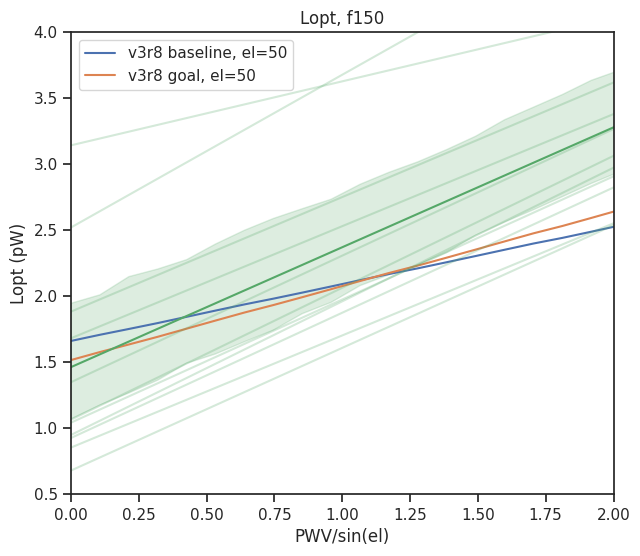

In [1022]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

plt.plot(
    optical_loading_detectors["pwv_sin_el"],
    1e12 * optical_loading_detectors["baseline"]["MF"]["MF_2"],
    label="v3r8 baseline, el=50",
)
plt.plot(
    optical_loading_detectors["pwv_sin_el"],
    1e12 * optical_loading_detectors["goal"]["MF"]["MF_2"],
    label="v3r8 goal, el=50",
)

xs = []
ys = []
for key in lopt_dict.keys():
    if "mv" in key:
        popt = lopt_dict[key]["150"]["popt"]
        y = func(optical_loading_detectors["pwv_sin_el"], *popt)
        for i in range(len(optical_loading_detectors["pwv_sin_el"])):
            xs.append(optical_loading_detectors["pwv_sin_el"][i])
            ys.append(y[i])
        plt.plot(optical_loading_detectors["pwv_sin_el"], y, "g", alpha=0.25)

df = pd.DataFrame({"PWV/sin(el)": xs, "Lopt (pW)": ys})
sns.lineplot(x="PWV/sin(el)", y="Lopt (pW)", data=df)
plt.legend()

plt.xlim(0, 2)
plt.ylim(0.5, 4)

plt.title("Lopt, f150")

plt.savefig("./plts/lopts/lopts_f150.png", dpi=600)
plt.savefig("./plts/lopts/lopts_f150.pdf", dpi=600)

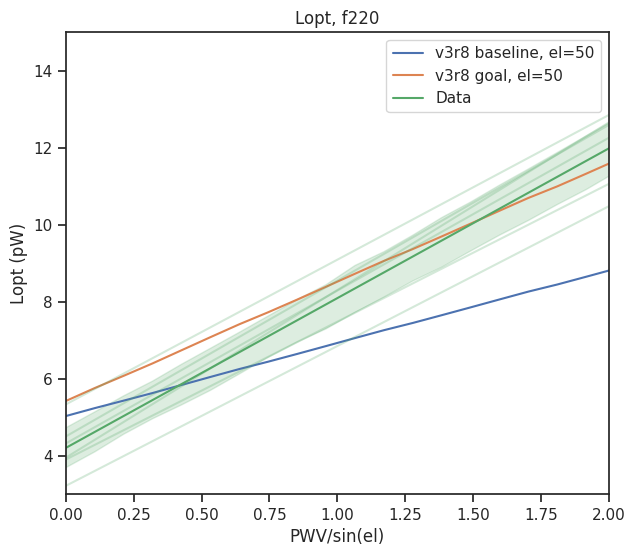

In [1023]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

plt.plot(
    optical_loading_detectors["pwv_sin_el"],
    1e12 * optical_loading_detectors["baseline"]["UHF"]["UHF_1"],
    label="v3r8 baseline, el=50",
)
plt.plot(
    optical_loading_detectors["pwv_sin_el"],
    1e12 * optical_loading_detectors["goal"]["UHF"]["UHF_1"],
    label="v3r8 goal, el=50",
)

xs = []
ys = []
for key in lopt_dict.keys():
    if "uv" in key:
        popt = lopt_dict[key]["220"]["popt"]
        y = func(optical_loading_detectors["pwv_sin_el"], *popt)
        for i in range(len(optical_loading_detectors["pwv_sin_el"])):
            xs.append(optical_loading_detectors["pwv_sin_el"][i])
            ys.append(y[i])
        plt.plot(optical_loading_detectors["pwv_sin_el"], y, "g", alpha=0.25)

df = pd.DataFrame({"PWV/sin(el)": xs, "Lopt (pW)": ys})
sns.lineplot(x="PWV/sin(el)", y="Lopt (pW)", data=df, label="Data")
plt.legend()

plt.xlim(0, 2)
plt.ylim(3, 15)

plt.title("Lopt, f220")

plt.savefig("./plts/lopts/lopts_f220.png", dpi=600)
plt.savefig("./plts/lopts/lopts_f220.pdf", dpi=600)

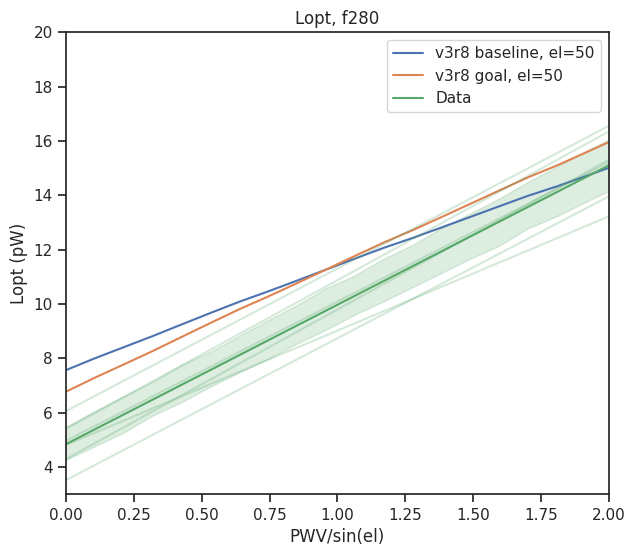

In [1024]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

plt.plot(
    optical_loading_detectors["pwv_sin_el"],
    1e12 * optical_loading_detectors["baseline"]["UHF"]["UHF_2"],
    label="v3r8 baseline, el=50",
)
plt.plot(
    optical_loading_detectors["pwv_sin_el"],
    1e12 * optical_loading_detectors["goal"]["UHF"]["UHF_2"],
    label="v3r8 goal, el=50",
)

xs = []
ys = []
for key in lopt_dict.keys():
    if "uv" in key:
        popt = lopt_dict[key]["280"]["popt"]
        y = func(optical_loading_detectors["pwv_sin_el"], *popt)
        for i in range(len(optical_loading_detectors["pwv_sin_el"])):
            xs.append(optical_loading_detectors["pwv_sin_el"][i])
            ys.append(y[i])
        plt.plot(optical_loading_detectors["pwv_sin_el"], y, "g", alpha=0.25)

df = pd.DataFrame({"PWV/sin(el)": xs, "Lopt (pW)": ys})
sns.lineplot(x="PWV/sin(el)", y="Lopt (pW)", data=df, label="Data")
plt.legend()

plt.xlim(0, 2)
plt.ylim(3, 20)

plt.title("Lopt, f280")

plt.savefig("./plts/lopts/lopts_f280.png", dpi=600)
plt.savefig("./plts/lopts/lopts_f280.pdf", dpi=600)

# Yields from Lopts

In [1490]:
sat_fname = "lopt_sat.pk"
with open(sat_fname, "rb") as f:
    sat_dict = pk.load(f)

In [1491]:
obs_ids = []
for key in sat_dict.keys():
    if "mv" in key:
        obs_ids.append(sat_dict[key]["obs_id"])

In [1493]:
times = mu.get_matching_obs(obs_ids)

In [1494]:
sats_low = np.zeros(times.shape[1])
sats_high = np.zeros(times.shape[1])
pwvs = 0
i = 0

for key in sat_dict.keys():
    if "mv" in key:
        sats_low += np.array(sat_dict[key]["low"])[times[i]]
        sats_high += np.array(sat_dict[key]["high"])[times[i]]
        pwvs = np.array(sat_dict[key]["pwv_sinel"])[times[i]]

        i += 1

pwvs_mf = np.concatenate([pwvs, pwvs])
labels_mf = np.concatenate([["f090"] * len(sats_low), ["f150"] * len(sats_high)])
yields_mf = np.concatenate([1 - (sats_low) / (11 * 860), 1 - (sats_high) / (11 * 860)])
df_mf = pd.DataFrame({"pwvs": pwvs_mf, "labels": labels_mf, "yields": yields_mf})

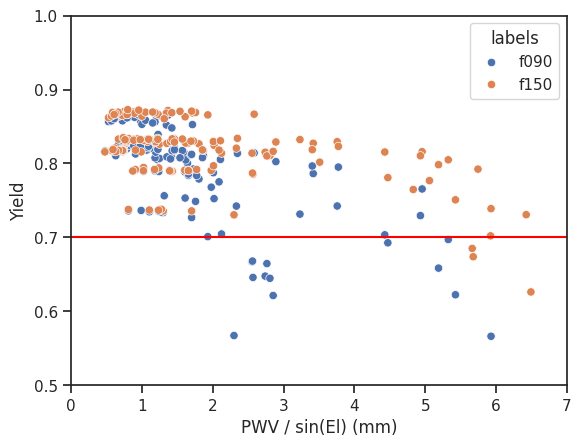

In [1495]:
sns.scatterplot(
    data=df_mf,
    x="pwvs",
    y="yields",
    hue="labels",
)

xmax = 7
plt.xlim(0, xmax)
plt.ylim(0.5, 1)

plt.xlabel("PWV / sin(El) (mm)")
plt.ylabel("Yield")

plt.hlines(0.7, 0, xmax, color="red")

plt.savefig("./plts/yield_pwv_mf.png", dpi=600)
plt.savefig("./plts/yield_pwv_mf.pdf", dpi=600)

In [1528]:
obs_ids = []
for key in sat_dict.keys():
    if "uv" in key:
        obs_ids.append(sat_dict[key]["obs_id"])
times = mu.get_matching_obs(obs_ids)

sats_low = np.zeros(times.shape[1])
sats_high = np.zeros(times.shape[1])
pwvs = 0
i = 0

for key in sat_dict.keys():
    if "uv" in key:
        sats_low += np.array(sat_dict[key]["low"])[times[i]]
        sats_high += np.array(sat_dict[key]["high"])[times[i]]
        pwvs = np.array(sat_dict[key]["pwv_sinel"])[times[i]]

        i += 1

pwvs_uhf = np.concatenate([pwvs, pwvs])
labels_uhf = np.concatenate([["f220"] * len(sats_low), ["f280"] * len(sats_high)])
yields_uhf = np.concatenate([1 - (sats_low) / (6 * 860), 1 - (sats_high) / (6 * 860)])
df_uhf = pd.DataFrame({"pwvs": pwvs_uhf, "labels": labels_uhf, "yields": yields_uhf})

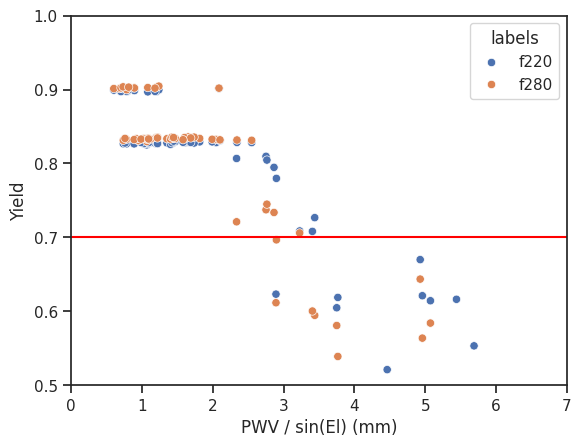

In [1529]:
sns.scatterplot(
    data=df_uhf,
    x="pwvs",
    y="yields",
    hue="labels",
)

xmax = 7.0
plt.xlim(0, xmax)
plt.ylim(0.5, 1)

plt.hlines(0.7, 0, xmax, color="red")

plt.xlabel("PWV / sin(El) (mm)")
plt.ylabel("Yield")

plt.savefig("./plts/yield_pwv_uhf.png", dpi=600)
plt.savefig("./plts/yield_pwv_uhf.pdf", dpi=600)

In [1530]:
pwvs_comb = np.concatenate([pwvs_mf, pwvs_uhf])
labels_comb = np.concatenate([labels_mf, labels_uhf])
yields_comb = np.concatenate([yields_mf, yields_uhf])
df_comb = pd.DataFrame(
    {"pwvs": pwvs_comb, "yields": yields_comb, "labels": labels_comb}
)

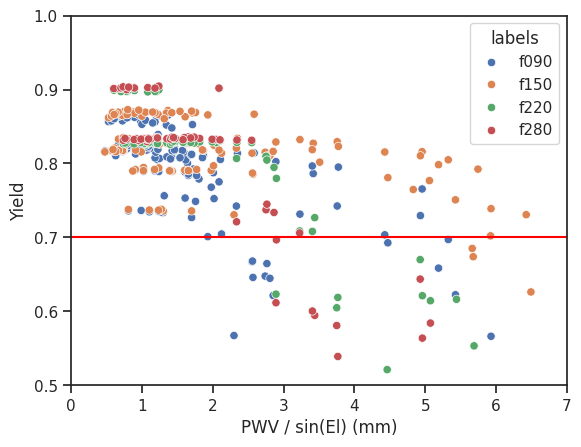

In [1531]:
sns.scatterplot(
    data=df_comb,
    x="pwvs",
    y="yields",
    hue="labels",
)

xmax = 7.0
plt.xlim(0, xmax)
plt.ylim(0.5, 1)

plt.hlines(0.7, 0, xmax, color="red")

plt.xlabel("PWV / sin(El) (mm)")
plt.ylabel("Yield")

plt.savefig("./plts/yield_pwv.png", dpi=600)
plt.savefig("./plts/yield_pwv.pdf", dpi=600)

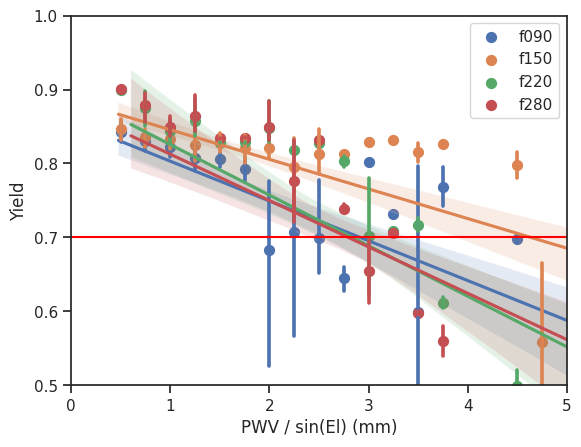

In [1546]:
order = 1
sns.regplot(
    data=df_comb.where(df_comb.labels == "f090"),
    x="pwvs",
    y="yields",
    x_bins=np.arange(0, 5, 0.250),
    order=order,
    label="f090",
)
sns.regplot(
    data=df_comb.where(df_comb.labels == "f150"),
    x="pwvs",
    y="yields",
    x_bins=np.arange(0, 5, 0.250),
    order=order,
    label="f150",
)
sns.regplot(
    data=df_comb.where(df_comb.labels == "f220"),
    x="pwvs",
    y="yields",
    x_bins=np.arange(0, 5, 0.250),
    order=order,
    label="f220",
)
sns.regplot(
    data=df_comb.where(df_comb.labels == "f280"),
    x="pwvs",
    y="yields",
    x_bins=np.arange(0, 5, 0.250),
    order=order,
    label="f280",
)

plt.xlim(0, 5)
plt.ylim(0.5, 1)

plt.hlines(0.7, 0, xmax, color="red")

plt.xlabel("PWV / sin(El) (mm)")
plt.ylabel("Yield")

plt.legend()
plt.savefig("./plts/yield_pwv.png", dpi=600)
plt.savefig("./plts/yield_pwv.pdf", dpi=600)

# Temperature debugging

In [1]:
from latcom.utils.optical_loading import UXM_dict, add_iv_info, get_fpa_temps, pwv_interp, therm_dict

import datetime as dt
import glob
import os

import dill as pk
import matplotlib.pyplot as plt
import numpy as np
import latcom.utils.map_utils as mu
from latcom.utils.optical_loading import UXM_dict, add_iv_info, get_fpa_temps, pwv_interp
from sotodlib import core
from sotodlib.io import hkdb

import matplotlib.pyplot as plt

In [2]:
ctx = core.Context("/global/cfs/cdirs/sobs/metadata/lat/contexts/smurf_detsets_local.yaml")
cfg = hkdb.HkConfig.from_yaml("../data/hkdb-lat.cfg")

In [3]:
ufm = "mv11"
start = dt.datetime(2025, 6, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2025, 6, 3, tzinfo=dt.timezone.utc)
obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='oper' and subtype=='iv'"
    " and stream_ids_list == 'ufm_{}'".format(ufm)
)

In [4]:
obs = obs_list[0]
old_field = "cryo-ls372-lsa22vr.temperatures.Channel_14_T"
lspec = hkdb.LoadSpec(
            cfg=cfg,
            start=obs["start_time"],
            end=obs["stop_time"],
            fields=[old_field],
        )
old_result = hkdb.load_hk(lspec, show_pb=False)

(0.0, 0.3)

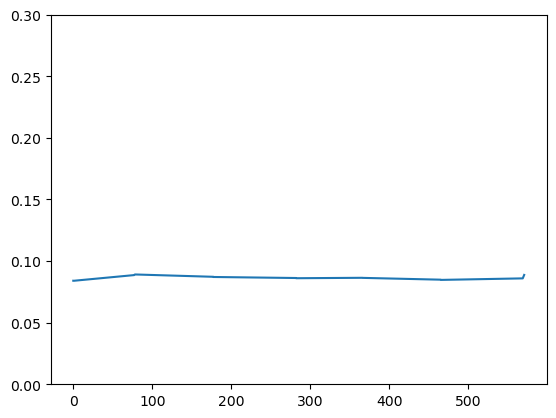

In [5]:
plt.plot(old_result.data[old_field][0]-old_result.data[old_field][0][0], old_result.data[old_field][1])
plt.ylim(0, 0.3)

In [6]:
start = dt.datetime(2026, 6, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2026, 6, 3, tzinfo=dt.timezone.utc)
obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='oper' and subtype=='iv'"
    " and stream_ids_list == 'ufm_{}'".format(ufm)
)
obs = obs_list[0]
new_field = "cryo-tauhk-1.tauhk_data_full.RTD_OT6_100mK_1_temperature"
lspec = hkdb.LoadSpec(
            cfg=cfg,
            start=obs["start_time"],
            end=obs["stop_time"],
            fields=[new_field],
        )
new_result = hkdb.load_hk(lspec, show_pb=False)

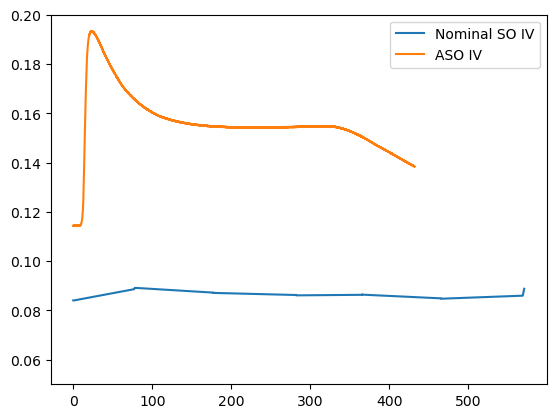

In [7]:
flags = np.where((new_result.data[new_field][1] < 0.2))[0]
plt.plot(old_result.data[old_field][0]-old_result.data[old_field][0][0], old_result.data[old_field][1], label="Nominal SO IV")
plt.plot(new_result.data[new_field][0][flags] - new_result.data[new_field][0][0], new_result.data[new_field][1][flags], label="ASO IV")
plt.ylim(0.05, 0.2)
plt.legend()

In [17]:
counts, edges = np.histogram(new_result.data[new_field][1], bins=int(len(new_result.data[new_field][0])/len(old_result.data[old_field][0])))


In [31]:
len_bins=int(len(new_result.data[new_field][0])/len(old_result.data[old_field][0]))
test = [np.mean(new_result.data[new_field][1][i*nbins:(i+1)*nbins]) for i in range(nbins)]

In [32]:
len(new_result.data[new_field][0])/len_bins

128.4

In [30]:
nbins

275